# VC Investments Data Analytics Project

**Dataset:** `investments_VC.csv` — ~54,000 startup funding records  
**Goal:** Explore global VC investment trends, top markets and funding distributions — and predict startup outcomes with ML

---

### Steps
1. Load & Explore
2. Clean the Data
3. Analyze — Top Countries
4. Analyze — Investment Trends Over Time
5. Analyze — Top Markets/Industries
6. Analyze — Funding Rounds Breakdown
7. Analyze — Company Status
8. Key Insights
9. Predicting Startup Success (ML Classification)

## 1. Load & Explore

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Nicer plots
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('investments_VC.csv', encoding='latin1')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
df.head(3)

Shape: (54294, 39)

Columns:
['permalink', 'name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Quick overview: data types, nulls, memory
df.info()

print("\nMissing values (%):")
missing = (df.isnull().sum() / len(df) * 100).round(1)
print(missing[missing > 0].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

## 2. Clean the Data

In [27]:
# ── Column names: strip whitespace
df.columns = df.columns.str.strip()

# ── funding_total_usd: remove spaces, commas → numeric
df['funding_total_usd'] = (
    df['funding_total_usd']
    .astype(str)
    .str.replace(r'[\s,]', '', regex=True)
    .replace('-', np.nan)
    .pipe(pd.to_numeric, errors='coerce')
)

# ── market: strip whitespace
df['market'] = df['market'].astype(str).str.strip()

# ── dates → datetime
for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# ── founded_year: fill from founded_at where missing
df['founded_year'] = df['founded_year'].fillna(df['founded_at'].dt.year)

print("Cleaned! Sample funding_total_usd values:")
print(df['funding_total_usd'].dropna().sort_values(ascending=False).head(10))
print(f"\nfunding_total_usd nulls: {df['funding_total_usd'].isnull().sum():,}")

Cleaned! Sample funding_total_usd values:
45815    3.007950e+10
36911    5.800000e+09
8664     5.700000e+09
7977     5.162513e+09
15315    3.500000e+09
9155     3.200000e+09
38289    2.600000e+09
14705    2.425700e+09
7328     2.400000e+09
15569    2.351140e+09
Name: funding_total_usd, dtype: float64

funding_total_usd nulls: 13,387


## 3. Top Countries by Number of Funded Startups

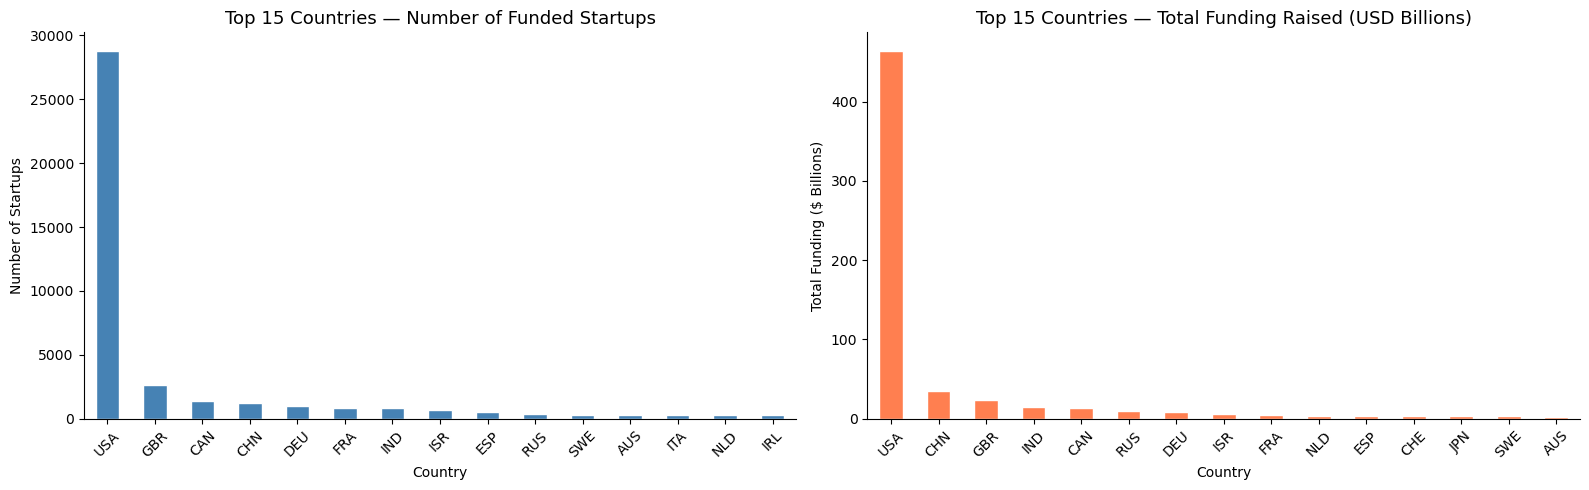


Top 5 by startup count:
country_code
USA    28793
GBR     2642
CAN     1405
CHN     1239
DEU      968
Name: count, dtype: int64


In [28]:
top_countries = df['country_code'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- Left: count of startups
top_countries.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Countries — Number of Funded Startups', fontsize=13)
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Startups')
axes[0].tick_params(axis='x', rotation=45)

# -- Right: total funding raised
top_funding = (
    df.groupby('country_code')['funding_total_usd']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
(top_funding / 1e9).plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 15 Countries — Total Funding Raised (USD Billions)', fontsize=13)
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Total Funding ($ Billions)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nTop 5 by startup count:")
print(top_countries.head())

## 4. Investment Trends Over Time

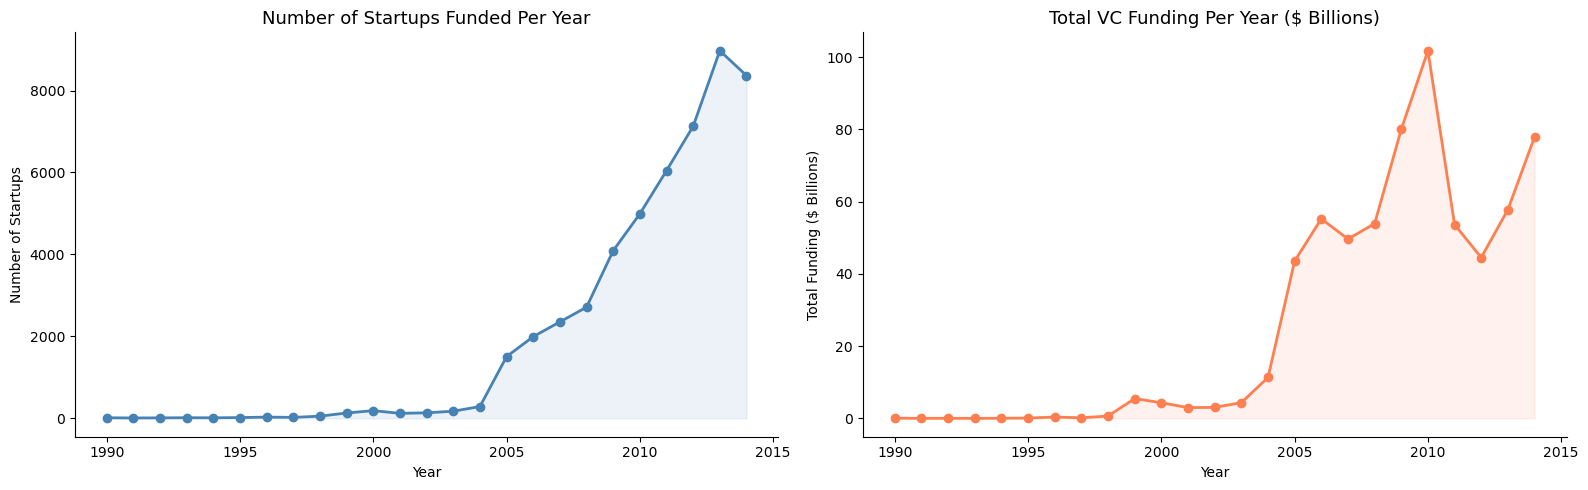

In [29]:
# Use first_funding_at year as the funding year
df['funding_year'] = df['first_funding_at'].dt.year

# Filter to reasonable range (1990–2015 to avoid sparse/outlier years)
yearly = df[(df['funding_year'] >= 1990) & (df['funding_year'] <= 2015)]

yearly_count = yearly.groupby('funding_year').size()
yearly_funding = yearly.groupby('funding_year')['funding_total_usd'].sum() / 1e9

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Startup count per year
yearly_count.plot(ax=axes[0], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Number of Startups Funded Per Year', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Startups')
axes[0].fill_between(yearly_count.index, yearly_count.values, alpha=0.1, color='steelblue')

# Total funding per year
yearly_funding.plot(ax=axes[1], marker='o', color='coral', linewidth=2)
axes[1].set_title('Total VC Funding Per Year ($ Billions)', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Funding ($ Billions)')
axes[1].fill_between(yearly_funding.index, yearly_funding.values, alpha=0.1, color='coral')

plt.tight_layout()
plt.show()

## 5. Top Markets / Industries

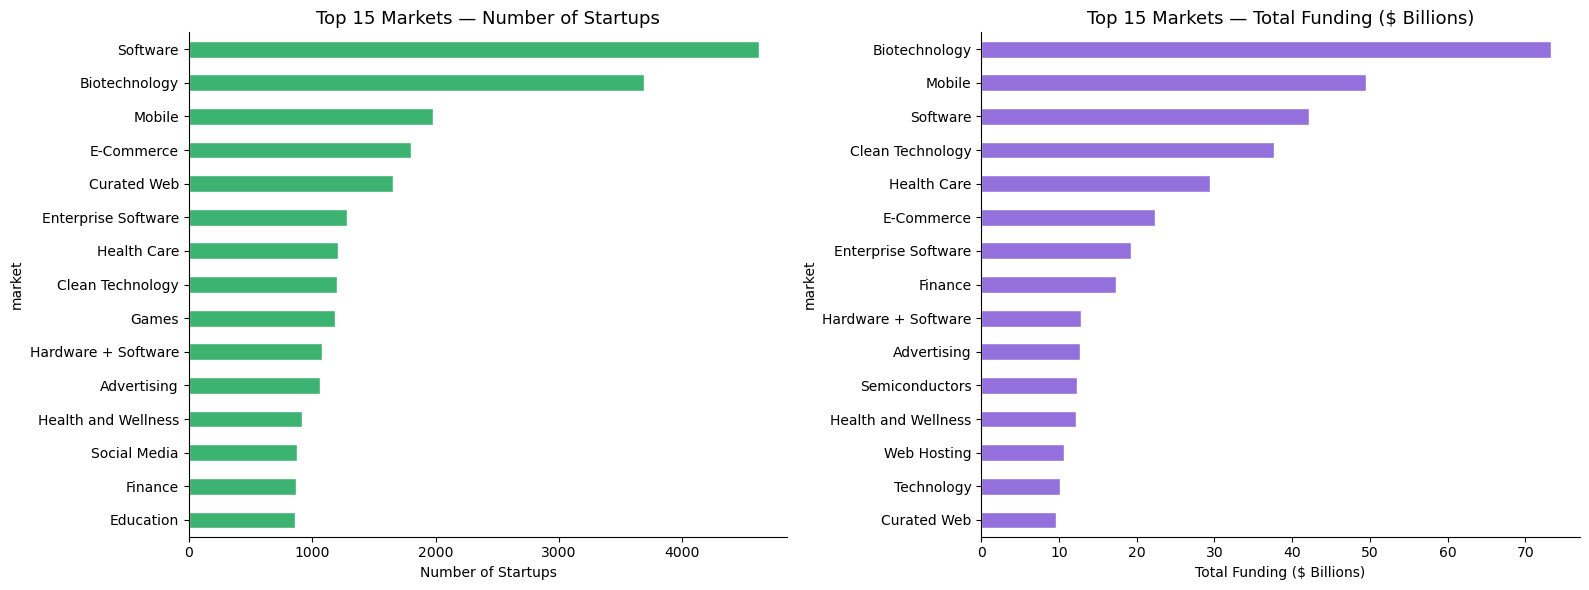

In [30]:
market_df = df[df['market'].notna() & (df['market'] != '') & (df['market'] != 'nan')]

top_markets_count = market_df['market'].value_counts().head(15)
top_markets_funding = (
    market_df.groupby('market')['funding_total_usd']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count
top_markets_count.plot(kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Top 15 Markets — Number of Startups', fontsize=13)
axes[0].set_xlabel('Number of Startups')
axes[0].invert_yaxis()

# Funding
(top_markets_funding / 1e9).plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Top 15 Markets — Total Funding ($ Billions)', fontsize=13)
axes[1].set_xlabel('Total Funding ($ Billions)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Funding Rounds Breakdown

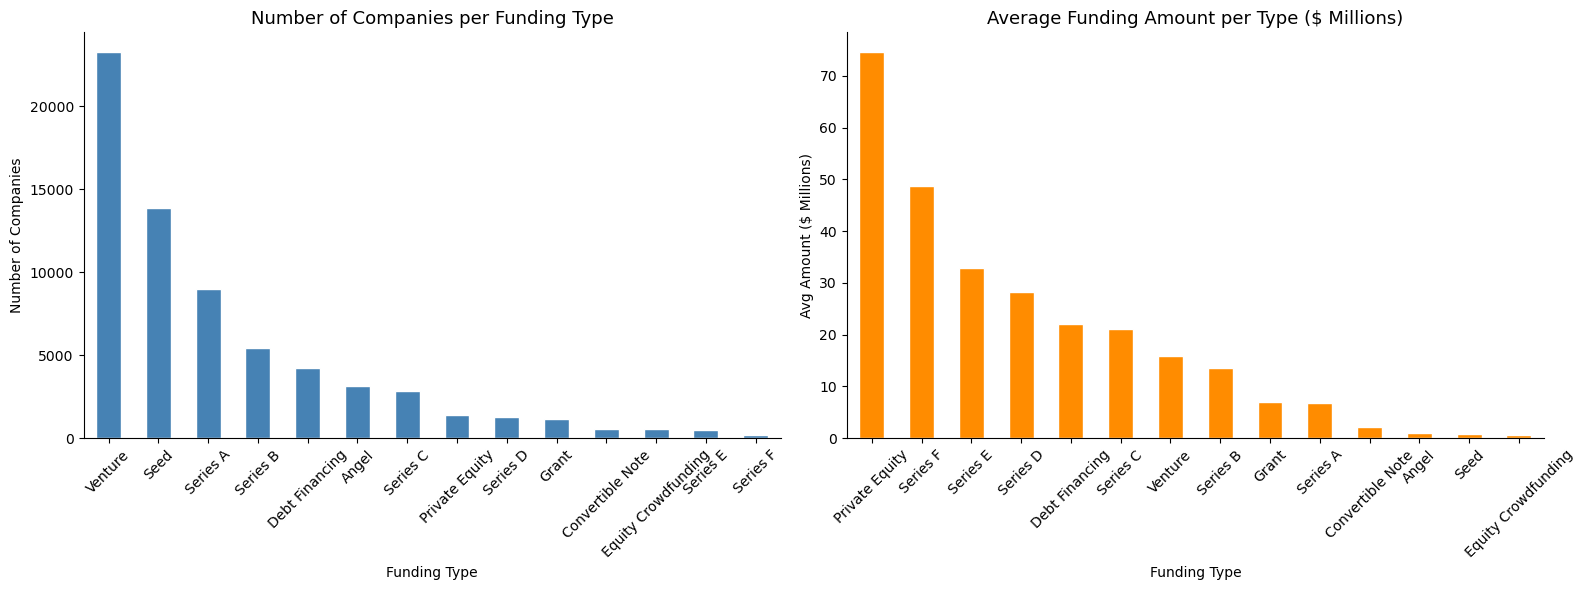

In [31]:
round_cols = ['seed', 'angel', 'venture', 'round_A', 'round_B', 'round_C',
              'round_D', 'round_E', 'round_F', 'equity_crowdfunding',
              'convertible_note', 'debt_financing', 'grant', 'private_equity']

round_labels = ['Seed', 'Angel', 'Venture', 'Series A', 'Series B', 'Series C',
                'Series D', 'Series E', 'Series F', 'Equity Crowdfunding',
                'Convertible Note', 'Debt Financing', 'Grant', 'Private Equity']

# Count companies that received each type (value > 0)
round_counts = pd.Series(
    [(df[col] > 0).sum() for col in round_cols],
    index=round_labels
).sort_values(ascending=False)

# Average amount per round type
round_avg = pd.Series(
    [df.loc[df[col] > 0, col].mean() / 1e6 for col in round_cols],
    index=round_labels
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

round_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Number of Companies per Funding Type', fontsize=13)
axes[0].set_xlabel('Funding Type')
axes[0].set_ylabel('Number of Companies')
axes[0].tick_params(axis='x', rotation=45)

round_avg.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Average Funding Amount per Type ($ Millions)', fontsize=13)
axes[1].set_xlabel('Funding Type')
axes[1].set_ylabel('Avg Amount ($ Millions)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Company Status Distribution

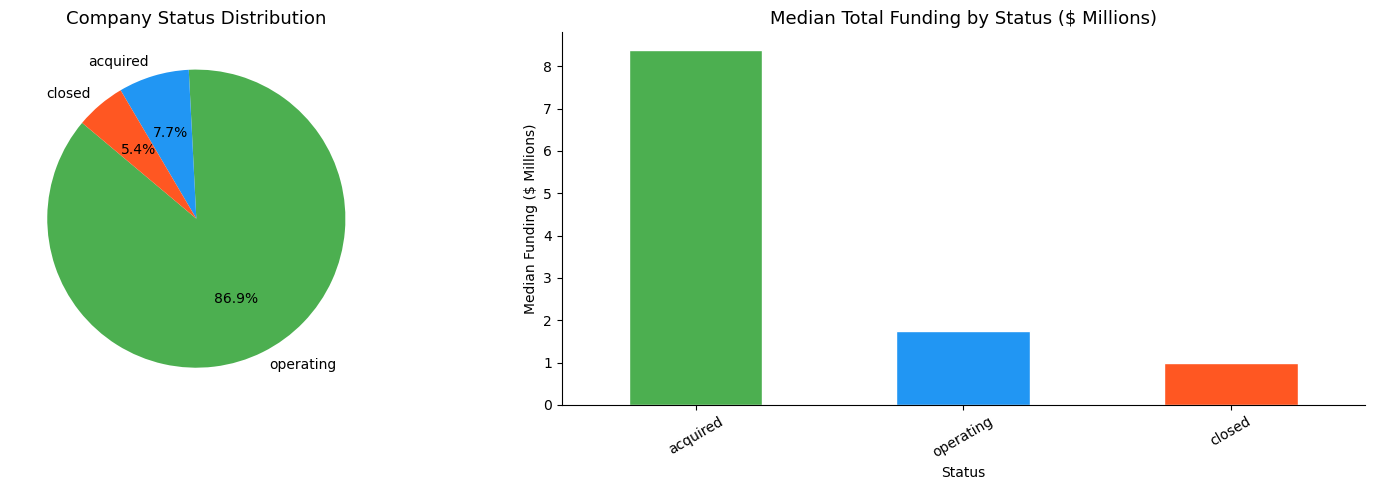


Status counts:
status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64


In [32]:
status_counts = df['status'].value_counts()
status_funding = df.groupby('status')['funding_total_usd'].median() / 1e6

colors = ['#4CAF50', '#2196F3', '#FF5722', '#9C27B0', '#FF9800']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie chart
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors[:len(status_counts)], startangle=140)
axes[0].set_title('Company Status Distribution', fontsize=13)

# Median funding by status
status_funding.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
                                                   color=colors[:len(status_funding)],
                                                   edgecolor='white')
axes[1].set_title('Median Total Funding by Status ($ Millions)', fontsize=13)
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Median Funding ($ Millions)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nStatus counts:")
print(status_counts)

## 8. Key Insights

### Countries
- The **USA dominates** with 28,793 startups — nearly 11x the next country (UK: 2,642).
- The USA also leads total funding by a massive margin: **$464B vs China's $35.6B** (2nd place).
- The top 5 countries are USA, UK, Canada, China, and Germany.

### Investment Trends Over Time
- VC activity grew steadily through the 2000s and **peaked in 2013** with ~8,972 startups funded in a single year.
- Total dollars invested peaked earlier, in **2010 at $101.8B**, suggesting deal sizes grew faster than deal counts in earlier years.

### Markets / Industries
- **Software** is the most common market (4,620 companies), followed by Biotechnology (3,688) and Mobile (1,983).
- However, **Biotechnology attracts the most total funding ($73.4B)** — ahead of Mobile ($49.5B) and Software ($42.2B), reflecting the capital-intensive nature of biotech.

### Funding Rounds
- **Venture** is the most common funding type (23,277 companies), followed by Seed (13,840) and Series A (9,003).
- As expected, later-stage rounds are much larger: avg **Series F = $48.8M**, Series E = $32.8M, Series D = $28.3M — vs Seed which is far smaller.
- The steep drop-off from Seed → Series A → B → C reflects the typical startup funnel — most companies don't make it to later rounds.

### Company Status
- **77%** of startups are still **operating**, 7% were **acquired**, and ~5% **closed**.
- Acquired companies raised a **median of $8.4M** — nearly 5x more than operating ones ($1.76M) and 8x more than closed ones ($1M).
- This suggests that **higher funding correlates with acquisition outcomes** — a hypothesis tested with ML in Section 9.

## 9. Predicting Startup Success (ML Classification)

**Question:** Can we predict whether a startup will be **acquired** or **close down**, based on its funding profile?

Binary classification:
- **Target:** `acquired` = 1, `closed` = 0
- **Features:** total funding, number of round types, years to first funding, country tier, market tier
- **Models:** Logistic Regression (baseline) + Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

model_df = df[df['status'].isin(['acquired', 'closed'])].copy()
model_df['target'] = (model_df['status'] == 'acquired').astype(int)

print(f'Dataset size: {len(model_df)} companies')
print(f"Acquired: {model_df['target'].sum()} | Closed: {(model_df['target']==0).sum()}")

In [ ]:
# Feature engineering
round_cols_ml = ['seed', 'angel', 'venture', 'round_A', 'round_B', 'round_C',
                  'round_D', 'round_E', 'round_F']

model_df['log_funding'] = np.log1p(model_df['funding_total_usd'].fillna(0))
model_df['num_round_types'] = (model_df[round_cols_ml] > 0).sum(axis=1)
model_df['years_to_funding'] = (
    model_df['first_funding_at'].dt.year - model_df['founded_year']
).clip(-2, 20)

top_c = df['country_code'].value_counts().head(10).index.tolist()
model_df['is_top_country'] = model_df['country_code'].isin(top_c).astype(int)
top_m = df['market'].value_counts().head(10).index.tolist()
model_df['is_top_market'] = model_df['market'].isin(top_m).astype(int)

feature_cols = ['log_funding', 'num_round_types', 'years_to_funding',
                'is_top_country', 'is_top_market']

model_clean = model_df[feature_cols + ['target']].dropna()
X = model_clean[feature_cols]
y = model_clean['target']

print(f'Training set size: {len(model_clean)} companies')
print(f'Class balance — Acquired: {y.sum()} ({y.mean():.1%}) | Closed: {(~y.astype(bool)).sum()}')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f'Logistic Regression  ROC-AUC: {lr_auc:.3f}')
print(f'Random Forest        ROC-AUC: {rf_auc:.3f}')
print()
print('Random Forest Classification Report:')
print(classification_report(y_test, rf.predict(X_test), target_names=['Closed', 'Acquired']))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for model, name, color in [
    (lr, 'Logistic Regression', 'steelblue'),
    (rf, 'Random Forest', 'coral')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_title('ROC Curve — Predicting Startup Acquisition', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Random Forest — Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### ML Findings

- **Random Forest outperforms Logistic Regression** — the relationship between features and outcomes is non-linear.
- **`log_funding` is the strongest predictor**: startups that raise more money are significantly more likely to be acquired.
- **`num_round_types`** is the second strongest signal — reaching multiple funding stages correlates with acquisition.
- Geography and market add modest predictive power, suggesting outcomes depend more on funding execution than location or sector alone.
- AUC meaningfully above 0.5 confirms that **funding profile is a statistically significant signal** for startup outcomes.